In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def read_fasta(filename):
    sequences = {}
    current_header = None

    with open(filename, "r") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                current_header = line[1:]
                sequences[current_header] = ""
            else:
                sequences[current_header] += line.upper()

    return sequences

In [3]:
sequences = read_fasta("data/sample.fasta")

print("Number of sequences:", len(sequences))

for name, sequence in sequences.items():
    print(name, ":", sequence)

Number of sequences: 3
gene_1 : ATGCGTACGTTAGC
gene_2 : GGCCATTAACGG
gene_3 : ATATGCGCGCAA


In [4]:
# Sequence Validation

In [5]:
def is_valid_dna(sequence):
    valid_bases = set("ATGC")
    return len(sequence) > 0 and set(sequence).issubset(valid_bases)

In [6]:
for name, sequence in sequences.items():
    print(name, ":", is_valid_dna(sequence))

gene_1 : True
gene_2 : True
gene_3 : True


In [7]:
##  Sequence Length and Base Composition

In [8]:
results = []

for name, sequence in sequences.items():

    results.append({
        "Sequence": name,
        "Length": len(sequence),
        "A": sequence.count("A"),
        "T": sequence.count("T"),
        "G": sequence.count("G"),
        "C": sequence.count("C")
    })

df = pd.DataFrame(results)

df

,Sequence,Length,A,T,G,C
0,gene_1,14,3,4,4,3
1,gene_2,12,3,2,4,3
2,gene_3,12,4,2,3,3


In [9]:
## GC Content

In [10]:
df["GC_Content"] = (
    (df["G"] + df["C"]) / df["Length"]
) * 100

df["GC_Content"] = df["GC_Content"].round(2)

df

,Sequence,Length,A,T,G,C,GC_Content
0,gene_1,14,3,4,4,3,50.00
1,gene_2,12,3,2,4,3,58.33
2,gene_3,12,4,2,3,3,50.00


In [11]:
## AT Content

In [12]:
df["AT_Content"] = (
    (df["A"] + df["T"]) / df["Length"]
) * 100

df["AT_Content"] = df["AT_Content"].round(2)

df

,Sequence,Length,A,T,G,C,GC_Content,AT_Content
0,gene_1,14,3,4,4,3,50.00,50.00
1,gene_2,12,3,2,4,3,58.33,41.67
2,gene_3,12,4,2,3,3,50.00,50.00


In [13]:
def get_complement(sequence):
    complement_map = {
        "A": "T",
        "T": "A",
        "G": "C",
        "C": "G"
    }

    return "".join(complement_map[base] for base in sequence)

In [14]:
df["Complement"] = [
    get_complement(sequence)
    for sequence in sequences.values()
]

df

,Sequence,Length,A,T,G,C,GC_Content,AT_Content,Complement
0,gene_1,14,3,4,4,3,50.00,50.00,TACGCATGCAATCG
1,gene_2,12,3,2,4,3,58.33,41.67,CCGGTAATTGCC
2,gene_3,12,4,2,3,3,50.00,50.00,TATACGCGCGTT


In [15]:
def get_reverse_complement(sequence):
    return get_complement(sequence)[::-1]

In [16]:
df["Reverse_Complement"] = [
    get_reverse_complement(sequence)
    for sequence in sequences.values()
]

df

,Sequence,Length,A,T,G,C,GC_Content,AT_Content,Complement,Reverse_Complement
0,gene_1,14,3,4,4,3,50.00,50.00,TACGCATGCAATCG,GCTAACGTACGCAT
1,gene_2,12,3,2,4,3,58.33,41.67,CCGGTAATTGCC,CCGTTAATGGCC
2,gene_3,12,4,2,3,3,50.00,50.00,TATACGCGCGTT,TTGCGCGCATAT


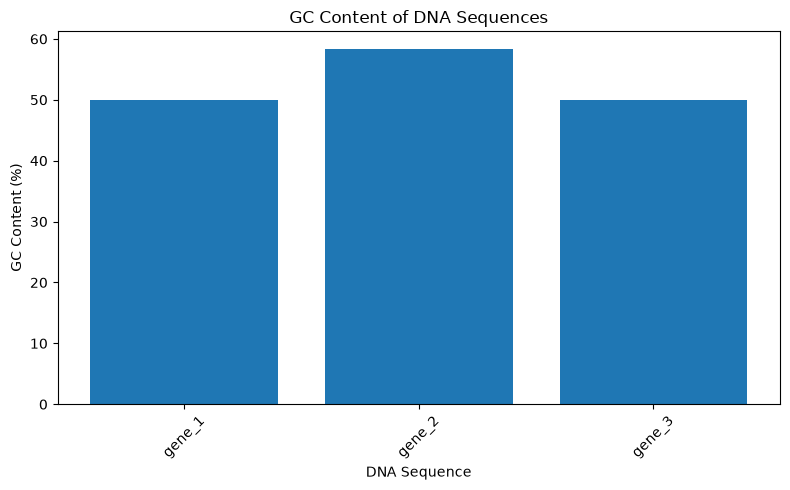

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(df["Sequence"], df["GC_Content"])

plt.xlabel("DNA Sequence")
plt.ylabel("GC Content (%)")
plt.title("GC Content of DNA Sequences")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
print("Average GC Content:", round(df["GC_Content"].mean(), 2), "%")
print("Average AT Content:", round(df["AT_Content"].mean(), 2), "%")
print("Average Sequence Length:", round(df["Length"].mean(), 2))

Average GC Content: 52.78 %
Average AT Content: 47.22 %
Average Sequence Length: 12.67


In [19]:
highest_gc = df.loc[df["GC_Content"].idxmax()]
lowest_gc = df.loc[df["GC_Content"].idxmin()]

print("Highest GC Content:")
print(highest_gc[["Sequence", "GC_Content"]])

print("\nLowest GC Content:")
print(lowest_gc[["Sequence", "GC_Content"]])

Highest GC Content:
Sequence      gene_2
GC_Content     58.33
Name: 1, dtype: object

Lowest GC Content:
Sequence      gene_1
GC_Content      50.0
Name: 0, dtype: object


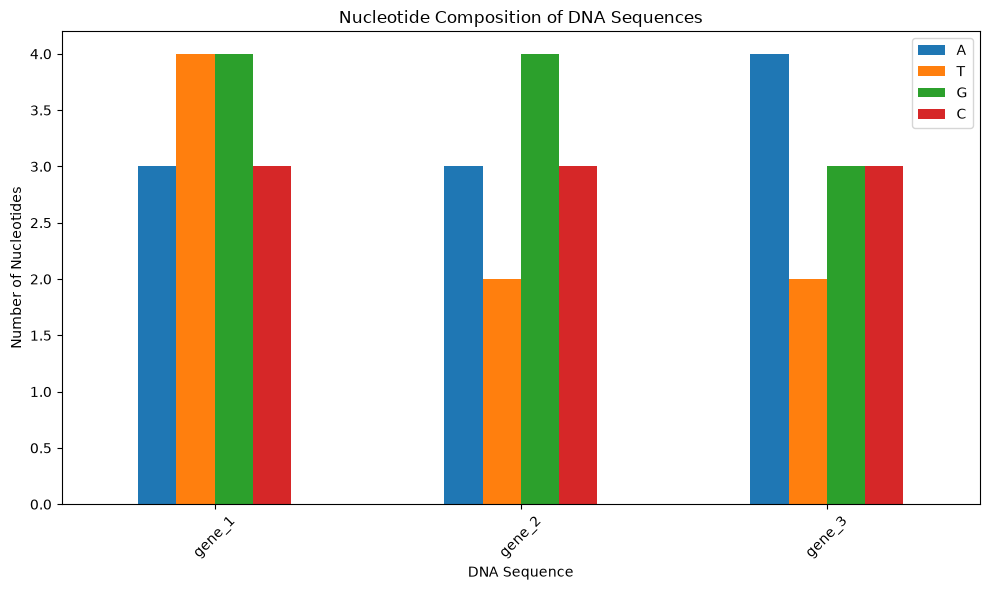

In [20]:
base_columns = ["A", "T", "G", "C"]

df.set_index("Sequence")[base_columns].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("DNA Sequence")
plt.ylabel("Number of Nucleotides")
plt.title("Nucleotide Composition of DNA Sequences")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [21]:
output_file = "results/analysis_results.csv"

df.to_csv(output_file, index=False)

print("Results saved successfully!")
print("File:", output_file)

Results saved successfully!
File: results/analysis_results.csv
